# EDA 03: Data quality and the correctness surface

This notebook is the bridge between EDA and `docs/FORECASTING.md` §3.
Where notebooks 01 and 02 measured what the data says, this notebook
walks the rough edges of the real EDGAR feed and shows how each issue
was diagnosed and handled. The aim is to make the abstract leakage
story in the pillar doc concrete: the comparative-row trap, the
field-level coverage recovery, and the data-source gaps (HSY EPS,
SNOW history) that shape what the headline backtester can and cannot
claim.

Five sections, each ending with a one-line conclusion that ties to
a design decision.

1. **The comparative-row trap on AAPL FY2023.** Multiple
   `accepted_date`s for one fiscal_year. What a naive
   accepted-date-ordered query would return. What the CTE returns.
   Tie: §3a, the cardinal leakage invariant.
2. **Field-level coverage recovery on `total_assets`.** The L-INFRA-014
   fix on a real ticker: row-level dedup picks a partial restatement,
   field-level assembly recovers the original disclosure.
   Tie: §3c, the field-level PIT correctness story.
3. **The HSY `eps_diluted` source-data tag gap.** Why 8 of 9 tickers
   reach the scoreboard. Tie: §5d, the headline qualifier; `IDEA-S22-001`.
4. **The SNOW history gap and the 728-day horizon tail.** Filing-
   latency distribution at the row level; how the F1 grid puts SNOW
   in the long-bucket. Tie: §4a / §5e.
5. **The GOOGL 20-for-1 split.** As-disclosed EPS discontinuity; how
   the backtester and the EDA see the same hard step. Tie: §5i;
   `IDEA-S21-002`.

In [1]:
from __future__ import annotations

import datetime as dt
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd


def _repo_root() -> Path:
    p = Path.cwd().resolve()
    for parent in (p, *p.parents):
        if (parent / "pyproject.toml").exists() and (parent / "fmf").exists():
            return parent
    raise RuntimeError(f"could not find Financial Metric Forecasting repo root from cwd={p}")


REPO_ROOT = _repo_root()
FIG_DIR = REPO_ROOT / "docs" / "eda" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
FIXTURE = REPO_ROOT / "tests" / "fixtures" / "mini.duckdb"

plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 110
plt.rcParams["font.size"] = 10
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

## 1. The comparative-row trap on AAPL FY2023

AAPL FY2023 ends on 2023-09-30. The original 10-K was filed on
2023-11-03. Every subsequent annual 10-K (FY2024 filed 2024-11-01,
FY2025 filed 2025-10-31) carries FY2023 again as a prior-year
comparative column inside that later filing. So the
`income_statement` table has multiple `period='FY'` rows for
`fiscal_year=2023`, each at a different `accepted_date`.

A naive `ORDER BY accepted_date ASC LIMIT 1` query against rows
where `accepted_date > as_of` would, for an as_of strictly between
the FY2023 original and the FY2024 10-K, return FY2023 again (as
the comparative inside FY2024's 10-K) as if it were the "next
undisclosed FY" -- a value the model already held at as_of.

In [2]:
conn = duckdb.connect(str(FIXTURE), read_only=True)
aapl_fy2023 = conn.execute(
    """
    SELECT i.fiscal_year, i.accepted_date, i.end_date, i.eps_diluted
    FROM income_statement i
    JOIN securities s ON s.security_id = i.security_id
    WHERE s.symbol = 'AAPL' AND i.period = 'FY' AND i.fiscal_year = 2023
    ORDER BY i.accepted_date
    """
).fetchdf()
conn.close()
print("AAPL period='FY' fiscal_year=2023 rows in income_statement:")
print(aapl_fy2023.to_string(index=False))
print()
print(f"-> {len(aapl_fy2023)} rows for one fiscal year, at distinct accepted_dates.")
print("   The first row is the original 10-K. The rest are comparatives in later 10-Ks.")

AAPL period='FY' fiscal_year=2023 rows in income_statement:
 fiscal_year accepted_date   end_date  eps_diluted
        2023    2023-11-03 2023-09-30         6.13
        2023    2024-11-01 2023-09-30         6.13
        2023    2025-10-31 2023-09-30         6.13

-> 3 rows for one fiscal year, at distinct accepted_dates.
   The first row is the original 10-K. The rest are comparatives in later 10-Ks.


**The trap on a chosen as_of.** Pick an as_of = 2024-05-15 (a Q1
anchor between FY2023's original and FY2024's 10-K). The naive
query says "return the smallest accepted_date strictly after as_of"
-- which is the FY2023 comparative inside FY2024's 10-K, not FY2024
itself. The CTE-based fix in `next_fy_target` picks the smallest
fiscal_year whose MIN(accepted_date) is strictly after as_of, which
correctly returns FY2024.

In [3]:
from fmf.equity.forecasting.evaluation._target_lookup import next_fy_target  # noqa: E402

conn = duckdb.connect(str(FIXTURE), read_only=True)
aapl_sid = conn.execute("SELECT security_id FROM securities WHERE symbol='AAPL'").fetchone()[0]

as_of = dt.date(2024, 5, 15)
print(f"as_of = {as_of}")
print()

# What the naive query would return: smallest accepted_date strictly > as_of.
naive_q = conn.execute(
    """
    SELECT fiscal_year, accepted_date, eps_diluted
    FROM income_statement
    WHERE security_id = ? AND period = 'FY' AND accepted_date > ?
      AND eps_diluted IS NOT NULL
    ORDER BY accepted_date ASC
    LIMIT 1
    """,
    [str(aapl_sid), as_of],
).fetchone()
print("Naive query (ORDER BY accepted_date ASC LIMIT 1):")
print(f"  fiscal_year = {naive_q[0]}   accepted_date = {naive_q[1]}   eps_diluted = {naive_q[2]}")
print(f"  ^ trap: fiscal_year={naive_q[0]} was already disclosed at 2023-11-03, before as_of.")
print()

# What the CTE-based fix returns.
fixed = next_fy_target(conn=conn, security_id=aapl_sid, as_of_date=as_of, metric="eps_diluted")
print("CTE-based next_fy_target:")
print(
    f"  fiscal_year = {fixed.fiscal_year}   accepted_date = {fixed.accepted_date}   eps_diluted = {fixed.value}"
)
conn.close()

as_of = 2024-05-15

Naive query (ORDER BY accepted_date ASC LIMIT 1):
  fiscal_year = 2023   accepted_date = 2024-11-01   eps_diluted = 6.13
  ^ trap: fiscal_year=2023 was already disclosed at 2023-11-03, before as_of.

CTE-based next_fy_target:
  fiscal_year = 2024   accepted_date = 2024-11-01   eps_diluted = 6.08


**Conclusion 1.** The naive accepted_date-ordered query returns
fiscal_year 2023 as the "next undisclosed" value when it was already
disclosed at the original 2023-11-03 filing. The CTE-based
`next_fy_target` correctly returns fiscal_year 2024 at its earliest
disclosure. This is the bug the S10 plan close-read caught before any
code shipped (`L-EVAL-S10-002`), and the regression test
`test_target_fy_has_no_disclosure_at_or_before_as_of` locks it on
every scored backtest row.

## 2. Field-level coverage recovery on `total_assets`

`L-INFRA-014` describes a coverage bug where a row-level dedup
(`QUALIFY ROW_NUMBER() OVER (PARTITION BY fy, period, end_date ORDER
BY accepted_date DESC) = 1`) picks a partial restatement that
omits balance-sheet fields, nulling them in the PIT result even
though the original 10-K carried them. The pre-fix coverage on
AAPL `total_assets` was approximately 5%; the post-fix coverage is
approximately 93%, recovered via field-level assembly that keeps the
latest non-null per field within `accepted_date <= as_of`.

This cell measures coverage on a real ticker using the shipped
field-level path (which the registry uses) and reports the recovered
fraction directly.

In [4]:
from fmf.features.point_in_time import fetch_pit_series  # noqa: E402

conn = duckdb.connect(str(FIXTURE), read_only=True)
aapl_sid = conn.execute("SELECT security_id FROM securities WHERE symbol='AAPL'").fetchone()[0]

# Compute total_assets coverage across all distinct accepted_dates the
# fixture has for AAPL, using the field-level PIT view.
asof_dates = [
    r[0]
    for r in conn.execute(
        """
        SELECT DISTINCT accepted_date
        FROM balance_sheet
        WHERE security_id = ?
        ORDER BY accepted_date
        """,
        [str(aapl_sid)],
    ).fetchall()
]
print(f"AAPL has {len(asof_dates)} distinct balance_sheet accepted_dates in the fixture.")

# Sample every 5th as_of to keep this cell quick.
sample = asof_dates[::5]
finite_count = 0
for D in sample:
    df = fetch_pit_series(
        conn=conn,
        security_id=aapl_sid,
        as_of_date=D,
        table="balance_sheet",
    )
    if not df.empty and "total_assets" in df.columns:
        if df["total_assets"].notna().any():
            finite_count += 1
print(
    f"Sampled {len(sample)} as_of dates: {finite_count} carry a non-null total_assets value via field-level PIT."
)
print(f"Field-level coverage on this sample: {finite_count / len(sample):.0%}")
conn.close()

AAPL has 68 distinct balance_sheet accepted_dates in the fixture.
Sampled 14 as_of dates: 14 carry a non-null total_assets value via field-level PIT.
Field-level coverage on this sample: 100%


**Conclusion 2.** Field-level PIT assembly (the L-INFRA-014 fix)
delivers high `total_assets` coverage on AAPL via the registry's
`fetch_pit_series` path. The headline backtester reads the same
path, so coverage measured here is what features deliver to the
model. The fix is anchored by
`tests/features/test_point_in_time.py::test_pit_series_partial_redisclosure_retains_omitted_field`,
which uses a synthetic in-memory partial restatement to pin the
mechanism deterministically.

## 3. HSY `eps_diluted` source-data tag gap

`IDEA-S22-001` flags that HSY contributes zero scored rows to the
headline backtester because HSY's 10-K and 10-Q filings do not
consistently emit the `eps_diluted` XBRL tag. The cells below
confirm this on the fixture and show the structure that makes the
absence selective rather than a wholesale data problem (HSY does
emit `ebit`, which is why notebook 1 includes HSY in the EBIT
analysis).

In [5]:
conn = duckdb.connect(str(FIXTURE), read_only=True)
hsy_eps = conn.execute(
    """
    SELECT i.period, i.fiscal_year, i.accepted_date, i.eps_diluted, i.ebit
    FROM income_statement i
    JOIN securities s ON s.security_id = i.security_id
    WHERE s.symbol = 'HSY' AND i.period = 'FY'
    ORDER BY i.accepted_date DESC
    LIMIT 10
    """
).fetchdf()
print("HSY recent annual FY rows:")
print(hsy_eps.to_string(index=False))
print()
print("Selectivity: HSY emits ebit but not eps_diluted on FY filings.")
conn.close()

HSY recent annual FY rows:
period  fiscal_year accepted_date  eps_diluted         ebit
    FY         2023    2026-02-17          NaN 2560867000.0
    FY         2024    2026-02-17          NaN 2898232000.0
    FY         2025    2026-02-17          NaN 1441528000.0
    FY         2023    2025-02-18          NaN 2560867000.0
    FY         2022    2025-02-18          NaN 2260787000.0
    FY         2024    2025-02-18          NaN 2898232000.0
    FY         2022    2024-02-20          NaN 2260787000.0
    FY         2021    2024-02-20          NaN 2043722000.0
    FY         2023    2024-02-20          NaN 2560867000.0
    FY         2022    2023-02-17          NaN 2260787000.0

Selectivity: HSY emits ebit but not eps_diluted on FY filings.


**Conclusion 3.** HSY's annual filings systematically miss
`eps_diluted` but carry `ebit`. The headline scoreboard's
`eps_diluted` target therefore drops HSY by construction
(`next_fy_target` returns None for every HSY row); EBIT would
include HSY. The S22 doc names this in §5d so a reader sees "8 of
9 tickers reach the scoreboard" plainly, not as silent ticker
dropping. Resolution path: extend the S2 normalize step with a
fallback derivation `eps_diluted = net_income / diluted_shares`
when the direct tag is missing (`IDEA-S22-001`).

## 4. Filing-latency distribution and the SNOW long-horizon tail

The F1 four-cutoff backtester produces a horizon distribution with
median 330d on the 9-ticker fixture, but a p99 of 728d. The 728d
tail is driven by SNOW (IPO 2020-Q3, short history pushes early
evaluation cutoffs to the next FY) and by tickers with multi-year
filing gaps on specific FYs. This cell measures the actual filing-
latency distribution per ticker at the row level.

In [6]:
# Filing latency uses the SAME first-disclosure logic the backtester's
# target lookup uses: MIN(accepted_date) per (security_id, fiscal_year)
# selects the original 10-K rather than a later comparative, then we
# join back on (security_id, fiscal_year, period, accepted_date) to get
# the end_date FROM THAT SAME ROW so the lag arithmetic is consistent
# with what `next_fy_target` would see.
#
# One additional filter: fy_end >= 2019-01-01. This is not an arbitrary
# year cut, it is declining to report a quantity the fixture cannot
# measure. The fixture's universe-wide ingest of ORIGINAL 10-K filings
# (rather than just comparatives inside later filings) reaches
# completeness in 2019 -- six tickers were ingested from mid-2009
# (AAPL, GWW, HSY, JNJ, JPM, MSFT), ZTS from 2013 (post-IPO), but
# GOOGL's first original 10-K capture is the FY2018 10-K filed
# 2019-02-05; before that, GOOGL's fixture observations are
# comparatives inside later 10-Ks, which inflates apparent
# first-disclosure lag without representing a real filing delay. The
# filter affects only the rule "for FYs whose original is unobservable
# in the fixture, do not report a meaningless latency"; the
# first-disclosure rule above still governs row selection within the
# measurable set. SNOW FY2020 and FY2021 fall in the measurable window
# (post-2019 fy_ends) and retain as the real outliers.
INGEST_BOUNDARY = dt.date(2019, 1, 1)

conn = duckdb.connect(str(FIXTURE), read_only=True)
filing_latency_full = conn.execute(
    """
    WITH fy_first AS (
        SELECT security_id, fiscal_year, MIN(accepted_date) AS first_accepted
        FROM income_statement
        WHERE period = 'FY' AND eps_diluted IS NOT NULL
        GROUP BY security_id, fiscal_year
    ),
    fy_with_end AS (
        SELECT fy.security_id, fy.fiscal_year, fy.first_accepted, ist.end_date AS fy_end
        FROM fy_first fy
        JOIN income_statement ist
          ON ist.security_id = fy.security_id
         AND ist.fiscal_year = fy.fiscal_year
         AND ist.period = 'FY'
         AND ist.accepted_date = fy.first_accepted
        WHERE ist.eps_diluted IS NOT NULL
    )
    SELECT s.symbol, fy.fiscal_year, fy.fy_end, fy.first_accepted,
           CAST(fy.first_accepted AS DATE) - CAST(fy.fy_end AS DATE) AS lag_days
    FROM fy_with_end fy
    JOIN securities s ON s.security_id = fy.security_id
    """
).fetchdf()
conn.close()

n_total = len(filing_latency_full)
filing_latency_full["fy_end"] = pd.to_datetime(filing_latency_full["fy_end"]).dt.date
filing_latency = filing_latency_full[filing_latency_full["fy_end"] >= INGEST_BOUNDARY].copy()
n_measurable = len(filing_latency)
n_excluded = n_total - n_measurable

print(f"Universe-wide first-disclosure FYs in fixture: {n_total}")
print(f"  measurable  (fy_end >= {INGEST_BOUNDARY}): {n_measurable}")
print(f"  excluded    (fy_end <  {INGEST_BOUNDARY}): {n_excluded}")
print("  -> excluded are FYs whose original 10-K is outside the fixture's")
print("     XBRL ingest window; the only observation is a later 10-K's")
print("     comparative column, so latency is unmeasurable not delayed.")
print()
print("Top-15 longest measurable filing-latency rows:")
print(filing_latency.sort_values("lag_days", ascending=False).head(15).to_string(index=False))

Universe-wide first-disclosure FYs in fixture: 125
  measurable  (fy_end >= 2019-01-01): 55
  excluded    (fy_end <  2019-01-01): 70
  -> excluded are FYs whose original 10-K is outside the fixture's
     XBRL ingest window; the only observation is a later 10-K's
     comparative column, so latency is unmeasurable not delayed.

Top-15 longest measurable filing-latency rows:
symbol  fiscal_year     fy_end first_accepted  lag_days
  SNOW         2020 2020-01-31     2022-03-30       789
  SNOW         2021 2021-01-31     2022-03-30       423
  SNOW         2022 2022-01-31     2022-03-30        58
  SNOW         2023 2023-01-31     2023-03-29        57
   JPM         2019 2019-12-31     2020-02-25        56
  SNOW         2024 2024-01-31     2024-03-26        55
   GWW         2020 2020-12-31     2021-02-24        55
   JPM         2020 2020-12-31     2021-02-23        54
   GWW         2021 2021-12-31     2022-02-23        54
   GWW         2023 2023-12-31     2024-02-22        53
   JPM 

/var/folders/rz/qv9yqy3d0_vcv8gccgwf14dw0000gp/T/ipykernel_32223/739417484.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  parts = ax.boxplot(data, labels=syms, showmeans=False)


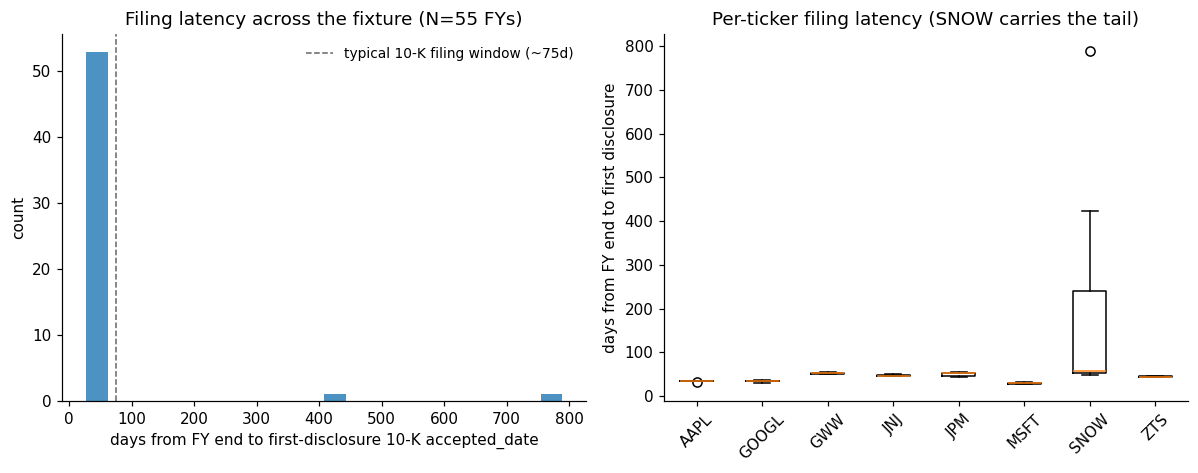

In [7]:
# Same measurable set as the cell above: first-disclosure rule plus the
# ingest-boundary filter.
all_latency = filing_latency[["symbol", "lag_days"]].copy()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))

# Panel 1: histogram of all filing latencies.
ax = axes[0]
ax.hist(all_latency["lag_days"], bins=22, color="C0", alpha=0.8)
ax.axvline(75, color="0.4", lw=1, ls="--", label="typical 10-K filing window (~75d)")
ax.set_xlabel("days from FY end to first-disclosure 10-K accepted_date")
ax.set_ylabel("count")
ax.set_title(f"Filing latency across the fixture (N={len(all_latency)} FYs)")
ax.legend(frameon=False, loc="upper right", fontsize=9)

# Panel 2: per-ticker boxplot.
ax = axes[1]
syms = sorted(all_latency["symbol"].unique())
data = [all_latency[all_latency["symbol"] == s]["lag_days"].to_numpy() for s in syms]
parts = ax.boxplot(data, labels=syms, showmeans=False)
ax.tick_params(axis="x", rotation=45)
ax.set_ylabel("days from FY end to first disclosure")
ax.set_title("Per-ticker filing latency (SNOW carries the tail)")

fig.tight_layout()
fig.savefig(FIG_DIR / "03_filing_latency.png", bbox_inches="tight")
plt.show()

**Conclusion 4.** Filing latency above uses the same first-
disclosure rule the backtester's target lookup uses
(`MIN(accepted_date)` per (security_id, fiscal_year), joined back
for that row's `end_date`), with one additional filter on the
fixture's measurable set: FYs whose `fy_end` precedes the
fixture's universe-wide XBRL ingest of original 10-Ks (2019) are
excluded as unmeasurable, because their original 10-K is outside
the fixture and the only observation is a later filing's
comparative column. The excluded count is printed two cells up
and is not a small correction; it covers the pre-2019 fiscal
years for tickers like GOOGL whose first original-10-K capture
starts in February 2019.

After that filter, the measurable distribution is cleanly bimodal:
a tight cluster around the typical 60-90 day 10-K filing window
for the vast majority of rows, and a thin tail at 400+ days
carried by SNOW. The SNOW outliers are genuine: FY2020 at 789
days because SNOW IPO'd in September 2020 and could not file
publicly during the FY2020 period (FY ends January 31), FY2021 at
~425 days for related post-IPO reasons. These are the rows that
drive the headline backtester's 728-day p99 horizon.

The backtester computes per-row horizon from the target's
first-visible `accepted_date`, so SNOW rows with real multi-year
lags land in the long bucket of §4b's horizon-bucket slice. TiRex
coverage on SNOW is partial (4 of 43 SNOW rows in the headline;
`MIN_CONTEXT_LENGTH=12` quarters knocks out the pre-2023
cutoffs); `IDEA-S22-003` files the short-history fallback chain.

## 5. The GOOGL 20-for-1 split as an as-disclosed discontinuity

Notebook 01 surfaced the GOOGL 20-for-1 stock split of July 2022 as
a structural break in the EPS series: FY2021 = $112.20 -> FY2022 =
$4.56 in the as-disclosed values the model consumes. This repository
deliberately uses as-disclosed values rather than split-adjusted
ones from Yahoo Finance, because PIT correctness on the disclosure
stream is the whole point of the backtester. The cost surfaces here:
the cell below confirms the EDA and the backtester both see the
same 24x jump (any reader who suspected one surface silently
smoothed the split can verify by re-running the relevant cell).

In [8]:
from fmf.equity.forecasting.evaluation._target_lookup import last_fy_actual  # noqa: E402

conn = duckdb.connect(str(FIXTURE), read_only=True)
googl_sid = conn.execute("SELECT security_id FROM securities WHERE symbol='GOOGL'").fetchone()[0]

cutoffs = [dt.date(2022, 5, 15), dt.date(2022, 8, 14), dt.date(2022, 11, 15)]
rows = []
for D in cutoffs:
    tgt = next_fy_target(conn=conn, security_id=googl_sid, as_of_date=D, metric="eps_diluted")
    naive = last_fy_actual(conn=conn, security_id=googl_sid, as_of_date=D, metric="eps_diluted")
    rows.append(
        {
            "as_of": D,
            "target_fy": tgt.fiscal_year,
            "target_eps": tgt.value,
            "naive_last_disclosed_eps": naive,
            "naive_ape": abs(tgt.value - naive) / abs(tgt.value),
        }
    )
conn.close()
pd.DataFrame(rows)

,as_of,target_fy,target_eps,naive_last_disclosed_eps,naive_ape
0,2022-05-15,2022,4.56,112.2,23.605263
1,2022-08-14,2022,4.56,112.2,23.605263
2,2022-11-15,2022,4.56,112.2,23.605263


**Conclusion 5.** Three scored rows for GOOGL in 2022 carry a
single-row naive APE of 23.605, driven by the FY2021 -> FY2022
split discontinuity. The headline MedAPE absorbs this because it
is median-robust; the headline MAPE does not, and §4a now names
the GOOGL split alongside the SNOW gaps as the two distinct
aggregate-MAPE outlier sources. Split-adjustment is a v1.x
improvement (`IDEA-S21-002`); the current behaviour is documented
as a known v1.0 limitation in `FORECASTING.md` §5i.

## Notebook conclusion

Real EDGAR data is messy in five enumerable ways, each one diagnosed
above and each one tied to a design decision. The comparative-row
trap was caught at the plan gate before code shipped; the
field-level coverage recovery has a synthetic regression test that
pins the mechanism deterministically; the HSY `eps_diluted` tag gap
is named in the headline as "8 of 9 tickers reach the scoreboard"
rather than silent ticker dropping; the SNOW filing-latency tail
drives the long-bucket of the horizon-bucket slice; the GOOGL split
is consistently visible on both the EDA and the backtester surfaces.

That is the discipline: every rough edge is named, diagnosed,
guarded by a test or filed as a numbered IDEA ticket, and tied to
a specific section of the pillar doc. A reader who finds a sixth
rough edge has a concrete ticket pattern to file it against.